# **AYUDANTÍA 15: Resolución Parte 1 Laboratorio 7**
28 de Noviembre 2024

Pablo Lourido y María Ignacia de la Cuadra F.


## **RESUMEN SQL:**

SQL (Structured Query Language) es un lenguaje utilizado para interactuar con bases de datos relacionales. Permite realizar operaciones como consultar, insertar, actualizar y eliminar datos en tablas. Aquí veremos los conceptos básicos usando las tablas PAISES y CIUDADES como ejemplos.


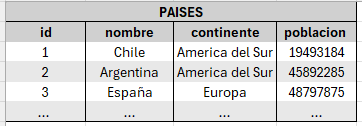

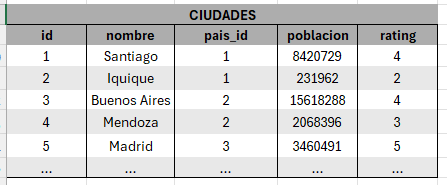

### **1. Tablas:**

Una tabla es una estructura que almacena datos en filas y columnas.

En las tablas:
- Las filas (tuplas) representan datos individuales.
- Las columnas (atributos) describen los datos.

Ejemplo:
La tabla `PAISES` almacena información de países con atributos como `id`, `nombre`, `continente` y `poblacion`.

### **2. Claves Primarias y Foráneas:**
- **Clave primaria (Primary Key):** Identifica de forma única cada fila en una tabla.

  Ejemplo: En `PAISES`, la columna `id` es la clave primaria.
- **Clave foránea (Foreign Key):** Relaciona una tabla con otra.
  Ejemplo: En `CIUDADES`, la columna `pais_id` es una clave foránea que se conecta con la clave primaria `id` en la tabla `PAISES`.

### **3. Operaciones básicas en SQL:**
- **SELECT (Consulta de datos)**: Se utiliza para recuperar datos de una tabla.

  Estructura básica:

  ```
  SELECT columna1, columna2
  FROM tabla
  WHERE condicion;
  ```

  Ejemplo: Queremos obtener el nombre y la poblacion de las ciudades

  ```
  SELECT nombre, poblacion
  FROM CIUDADES;
  ```
- **WHERE (Filtrar datos):** Permite filtrar los resultados basados en condiciones.

  Ejemplo: queremos obtener las ciudades con una población mayor a 1.000.000 de habitantes
  ```
SELECT nombre, poblacion
FROM CIUDADES
WHERE poblacion > 1000000;
  ```

- **INSERT (Agregar datos):** Permite insertar nuevas filas en una tabla.

  Estructura básica:
  ```
INSERT INTO tabla (columna1, columna2)
VALUES (valor1, valor2);
  ```
  Ejemplo: Agregar un nuevo país
  ```
INSERT INTO PAISES (id, nombre, continente, poblacion)
VALUES (4, 'Perú', 'América del Sur', 33000000);
  ```
- **UPDATE (Actualizar datos):** Modifica los valores de una o más filas.

  Ejemplo: Actualiar la población de Madrid:
  ```
  UPDATE CIUDADES
  SET poblacion = 3500000
  WHERE nombre = 'Madrid';
  ```
- **DELETE (Eliminar datos):** Elimina filas de una tabla.

  Ejemplo: Eliminar un país por su ID:
  ```
  DELETE FROM PAISES
  WHERE id = 4;
  ```

### **4. Relaciones entre tablas:**

Al tener varias tablas relacionadas, es común realizar consultas que combinen datos.

- **JOIN (Unir tablas)**: Permite combinar datos de dos tablas basadas en una relación.

  Ejemplo: Obtener el nombre de las ciudades y su país correspondiente:
  ```
SELECT CIUDADES.nombre AS ciudad, PAISES.nombre AS pais
FROM CIUDADES
JOIN PAISES
ON CIUDADES.pais_id = PAISES.id;
  ```

### **5. Agrupamiento y Agregación de Datos**
- **GROUP BY:** Agrupa filas con valores en común para realizar cálculos sobre estas.

  Ejemplo: Calcular la población total por continente:
  ```
SELECT PAISES.continente, SUM(CIUDADES.poblacion) AS poblacion_total
FROM CIUDADES
JOIN PAISES ON CIUDADES.pais_id = PAISES.id
GROUP BY PAISES.continente;
  ```

- **HAVING:** Filtra los resultados después de haber agrupado los datos.

  Ejemplo: Mostrar los continentes con una población total mayor a 10 millones:
  ```
SELECT PAISES.continente, SUM(CIUDADES.poblacion) AS poblacion_total
FROM CIUDADES
JOIN PAISES ON CIUDADES.pais_id = PAISES.id
GROUP BY PAISES.continente
HAVING SUM(CIUDADES.poblacion) > 10000000;
  ```



### **6. Ordenar Datos**
- **ORDER BY:** Permite ordenar los resultados en forma ascendente (`ASC`) o descendente (`DESC`).

  Ejemplo: Ordenar las ciudades por población en orden descendente:
  ```
SELECT nombre, poblacion
FROM CIUDADES
ORDER BY poblacion DESC;
  ```

### **7. Subconsultas**
Las subconsultas son consultas anidadas dentro de otras consultas.

  Ejemplo: Obtener las ciudades con una población mayor al promedio:

```
SELECT nombre, poblacion
FROM CIUDADES
WHERE poblacion > (
    SELECT AVG(poblacion)
    FROM CIUDADES
);
```

### **8. Combinar Resultados**
- **UNION:** Combina los resultados de dos o más consultas eliminando duplicados.

  Ejemplo: Obtener una lista de nombres de países y ciudades (sin duplicados):

  ```
SELECT nombre
FROM PAISES
UNION
SELECT nombre
FROM CIUDADES;
  ```
- **UNION ALL:** Combina los resultados de dos o más consultas manteniendo duplicados.

  Ejemplo: Obtener todos los nombres, incluyendo duplicados:
  ```
SELECT nombre
FROM PAISES
UNION ALL
SELECT nombre
FROM CIUDADES;
  ```


### **9. Funciones Útiles:**
- **COUNT():** Cuenta el número de filas.

  Ejemplo: Encontrar el total de ciudades
  ```
SELECT COUNT(*)
FROM CIUDADES;
  ```
- **SUM():** Suma valores numéricos.

  Ejemplo: Encontrar la población total de todas las ciudades
  ```
SELECT SUM(poblacion)
FROM CIUDADES;
  ```
- **AVG():** Calcula el promedio.

  Ejemplo: Calcular el promedio de la población de todas las ciudades
  ```
SELECT AVG(poblacion)
FROM CIUDADES;
  ```
- **MIN():** Encuentra el valor mínimo.

  Ejemplo: Encontrar la ciudad con la población más baja
  ```
SELECT MIN(poblacion) AS poblacion_minima
FROM CIUDADES;
  ```
- **MAX():** Encuentra el valor máximo.

  Ejemplo: Encontrar la ciudad con la población más alta
  ```
SELECT MAX(poblacion) AS poblacion_maxima
FROM CIUDADES;
  ```



## **Laboratorio 7 Parte 1:**

### Antes de partir trabajando:

Primero, importamos las librerías que utilizaremos:



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

Luego, visualizamos la estructura de cada una de las tablas de nuestra base de datos (`flights.db`).

In [3]:
conn = sqlite3.connect('flights.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tablas = cursor.fetchall()

for tabla in tablas:
    nombre_tabla = tabla[0]
    print(f"Estructura de la tabla: {nombre_tabla}")
    cursor.execute(f"PRAGMA table_info('{nombre_tabla}');")
    estructura = cursor.fetchall()
    for columna in estructura:
        print(f"  - {columna[1]} ({columna[2]}), NOT NULL: {bool(columna[3])}, PK: {bool(columna[5])}")
    print()
cursor.close()


Estructura de la tabla: aircrafts_data
  - aircraft_code (character(3)), NOT NULL: True, PK: False
  - model (jsonb), NOT NULL: True, PK: False
  - range (INTEGER), NOT NULL: True, PK: False

Estructura de la tabla: airports_data
  - airport_code (character(3)), NOT NULL: True, PK: False
  - airport_name (jsonb), NOT NULL: True, PK: False
  - city (jsonb), NOT NULL: True, PK: False
  - coordinates (point), NOT NULL: True, PK: False
  - timezone (TEXT), NOT NULL: True, PK: False

Estructura de la tabla: boarding_passes
  - ticket_no (character(13)), NOT NULL: True, PK: False
  - flight_id (INTEGER), NOT NULL: True, PK: False
  - boarding_no (INTEGER), NOT NULL: True, PK: False
  - seat_no (character varying(4)), NOT NULL: True, PK: False

Estructura de la tabla: bookings
  - book_ref (character(6)), NOT NULL: True, PK: False
  - book_date (timestamp with time zone), NOT NULL: True, PK: False
  - total_amount (numeric(10,2)), NOT NULL: True, PK: False

Estructura de la tabla: flights
  -

Ahora ya estamos listos para partir con el laboratorio

### a) Muestre todos los vuelos que estén programados para despegar desde un aeropuerto específico.

In [4]:
aeropuerto = 'KZN' # Seleccionamos el aeropuerto KZN como ejemplo

connection = sqlite3.connect('flights.db')
query = f"""
SELECT DISTINCT *
FROM flights
WHERE departure_airport = '{aeropuerto}'
"""

df = pd.read_sql_query(query, connection)
connection.close()
display(df)

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,11847,PG0498,2017-09-12 10:15:00+03,2017-09-12 14:55:00+03,KZN,IKT,Scheduled,319,\N,\N
1,12012,PG0621,2017-08-26 16:05:00+03,2017-08-26 17:00:00+03,KZN,MQF,Scheduled,CR2,\N,\N
2,11562,PG0203,2017-08-14 17:45:00+03,2017-08-14 18:40:00+03,KZN,DME,Arrived,321,2017-08-14 17:47:00+03,2017-08-14 18:42:00+03
3,11563,PG0203,2017-08-03 17:45:00+03,2017-08-03 18:40:00+03,KZN,DME,Arrived,321,2017-08-03 17:49:00+03,2017-08-03 18:44:00+03
4,11564,PG0203,2017-09-14 17:45:00+03,2017-09-14 18:40:00+03,KZN,DME,Cancelled,321,\N,\N
...,...,...,...,...,...,...,...,...,...,...
466,12028,PG0621,2017-07-26 16:05:00+03,2017-07-26 17:00:00+03,KZN,MQF,Arrived,CR2,2017-07-26 16:11:00+03,2017-07-26 17:05:00+03
467,12029,PG0621,2017-08-15 16:05:00+03,2017-08-15 17:00:00+03,KZN,MQF,Arrived,CR2,2017-08-15 16:09:00+03,2017-08-15 17:04:00+03
468,12030,PG0621,2017-07-17 16:05:00+03,2017-07-17 17:00:00+03,KZN,MQF,Arrived,CR2,2017-07-17 16:10:00+03,2017-07-17 17:06:00+03
469,12031,PG0621,2017-09-13 16:05:00+03,2017-09-13 17:00:00+03,KZN,MQF,Scheduled,CR2,\N,\N


### b) Liste los códigos de los aeropuertos con vuelos programados entre un rango de fechas específico, por ejemplo, de ’2017-08-10’ a ’2017-09-05’.

In [5]:
fecha_inicio = '2017-08-10'
fecha_fin = '2017-09-05'

query = f"""
SELECT DISTINCT departure_airport AS airport
FROM flights
WHERE scheduled_departure BETWEEN '{fecha_inicio}' AND '{fecha_fin}'
UNION
SELECT DISTINCT arrival_airport AS airport
FROM flights
WHERE scheduled_departure BETWEEN '{fecha_inicio}' AND '{fecha_fin}';
"""

connection = sqlite3.connect('flights.db')
df = pd.read_sql_query(query, connection)
connection.close()
display(df)

,airport
0,AAQ
1,ABA
2,AER
3,ARH
4,ASF
...,...
99,VKT
100,VOG
101,VOZ
102,VVO


### c) Encuentre los pasajeros que tienen más de un ticket reservado.

In [6]:
connection = sqlite3.connect('flights.db')

query = """
SELECT passenger_id, COUNT(*) AS ticket_count
FROM tickets
GROUP BY passenger_id
HAVING COUNT(*) > 1;
"""

df = pd.read_sql_query(query, connection)
connection.close()
display(df)

,passenger_id,ticket_count


No existen pasajeros con más de un ticket reservado

### d) Encuentre los 15 pares Origen-Destino mas comunes y cuántos vuelos operan en cada uno.

In [7]:
connection = sqlite3.connect('flights.db')

query = """
SELECT departure_airport, arrival_airport, COUNT(*) as flight_count
FROM flights
GROUP BY departure_airport, arrival_airport
ORDER BY flight_count DESC
LIMIT 15;
"""

df = pd.read_sql_query(query, connection)
connection.close()
display(df)

,departure_airport,arrival_airport,flight_count
0,LED,SVO,305
1,SVO,LED,305
2,DME,LED,244
3,LED,DME,244
4,BZK,DME,183
5,BZK,SVO,183
6,BZK,VKO,183
7,DME,BZK,183
8,LED,VKO,183
9,SVO,BZK,183


### e) Identifique los 25 vuelos con el mayor ingreso total y muestre su ruta, avión utilizado y monto generado.

In [8]:
import json
connection = sqlite3.connect('flights.db')

query = """
SELECT f.flight_id, f.departure_airport || ' -> ' || f.arrival_airport AS route, a.model AS aircraft_model, SUM(tf.amount) AS total_revenue
FROM flights AS f
JOIN ticket_flights AS tf ON f.flight_id = tf.flight_id
JOIN tickets AS t ON tf.ticket_no = t.ticket_no
JOIN aircrafts_data AS a ON f.aircraft_code = a.aircraft_code
GROUP BY f.flight_id, route, aircraft_model
ORDER BY total_revenue DESC
LIMIT 25;
"""

df = pd.read_sql_query(query, connection)
connection.close()
df['aircraft_model'] = df['aircraft_model'].apply(lambda x: json.loads(x)['en'])
display(df)

,flight_id,route,aircraft_model,total_revenue
0,2354,DME -> KHV,Boeing 767-300,17146600
1,26212,KHV -> DME,Boeing 767-300,17023600
2,2364,DME -> KHV,Boeing 767-300,16962100
3,2330,DME -> KHV,Boeing 767-300,16900600
4,2329,DME -> KHV,Boeing 767-300,16894400
5,2341,DME -> KHV,Boeing 767-300,16839100
6,2344,DME -> KHV,Boeing 767-300,16777600
7,2369,DME -> KHV,Boeing 767-300,16777600
8,2325,DME -> KHV,Boeing 767-300,16593100
9,2332,DME -> KHV,Boeing 767-300,16593100


### d) Calcule el ingreso total generado por cada avión.

In [9]:
connection = sqlite3.connect('flights.db')

query = """
SELECT
    a.aircraft_code,
    a.model AS aircraft_model,
    SUM(tf.amount) AS total_revenue
FROM
    flights AS f
JOIN
    ticket_flights AS tf ON f.flight_id = tf.flight_id
JOIN
    aircrafts_data AS a ON f.aircraft_code = a.aircraft_code
GROUP BY
    a.aircraft_code, aircraft_model
ORDER BY
    total_revenue DESC;
"""

df = pd.read_sql_query(query, connection)
df['aircraft_model'] = df['aircraft_model'].apply(lambda x: json.loads(x)['en'])

connection.close()

display(df)


,aircraft_code,aircraft_model,total_revenue
0,SU9,Sukhoi Superjet-100,5114484700
1,763,Boeing 767-300,4371277100
2,773,Boeing 777-300,3431205500
3,319,Airbus A319-100,2706163100
4,CR2,Bombardier CRJ-200,1982760500
5,321,Airbus A321-200,1638164100
6,733,Boeing 737-300,1426552100
7,CN1,Cessna 208 Caravan,96373800
